In [2]:
# 1. Clone the official LLaVA repository
!git clone https://github.com/haotian-liu/LLaVA.git
%cd LLaVA

# 2. PATCH: Remove strict version pinning for Python 3.12 compatibility
!sed -i 's/torch==2.1.2/torch/g' pyproject.toml
!sed -i 's/torchvision==0.16.2/torchvision/g' pyproject.toml
!sed -i 's/sentencepiece==0.1.99/sentencepiece/g' pyproject.toml

# 3. Install LLaVA and memory-saving libraries
!pip install --upgrade pip
!pip install -e .
!pip install bitsandbytes accelerate

Cloning into 'LLaVA'...
remote: Enumerating objects: 2297, done.
remote: Total 2297 (delta 0), reused 0 (delta 0), pack-reused 2297 (from 1)
Receiving objects: 100% (2297/2297), 13.71 MiB | 29.13 MiB/s, done.
Resolving deltas: 100% (1404/1404), done.
/kaggle/working/LLaVA
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.2 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Obtaining file:///kaggle/working/LLaVA
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 17.0 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependenc

In [ ]:
import os
os._exit(00)

In [1]:
import sys
import os

# --- KERNEL RESTART FIX ---
# Make sure Kaggle knows where to look for LLaVA after the restart
sys.path.append("/kaggle/working/LLaVA")
os.chdir("/kaggle/working/LLaVA")
# --------------------------

import json
import torch
from tqdm import tqdm
from PIL import Image
from llava.model.builder import load_pretrained_model
from llava.mm_utils import get_model_name_from_path, tokenizer_image_token
from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN, DEFAULT_IM_START_TOKEN, DEFAULT_IM_END_TOKEN
from llava.conversation import conv_templates

# 1. ACTUAL KAGGLE PATHS
BENCHMARK_PATH = "/kaggle/input/datasets/mohammadaliabdullah/small-set-questions/Xview_small-set_200_questions_val_images.json"
IMAGE_DIR = "/kaggle/input/datasets/mohammadaliabdullah/xview-dataset/Xview data set/val_images"
OUTPUT_PATH = "/kaggle/working/baseline_results.json" 

# 2. Load Vanilla LLaVA-1.5 (7B parameters) in 4-bit mode for Kaggle
model_path = "liuhaotian/llava-v1.5-7b"
model_name = get_model_name_from_path(model_path)

print("Loading LLaVA-1.5 baseline...")
tokenizer, model, image_processor, context_len = load_pretrained_model(
    model_path=model_path, 
    model_base=None, 
    model_name=model_name, 
    load_4bit=True, # Crucial for Kaggle T4 GPUs
    device_map="auto"
)

# 3. Load your custom benchmark
with open(BENCHMARK_PATH, "r") as f:
    eval_questions = json.load(f)

results = []

# 4. Loop through and test the model safely
print(f"Testing {len(eval_questions)} multi-hop questions...")
for item in tqdm(eval_questions):
    # Construct the exact path to the image
    image_file = os.path.join(IMAGE_DIR, item['image'])
    raw_prompt = item["text"]
    
    try:
        # --- PROPER LLAVA INFERENCE LOGIC ---
        # 4a. Format the prompt with the required Image Tokens
        if model.config.mm_use_im_start_end:
            prompt = DEFAULT_IM_START_TOKEN + DEFAULT_IMAGE_TOKEN + DEFAULT_IM_END_TOKEN + '\n' + raw_prompt
        else:
            prompt = DEFAULT_IMAGE_TOKEN + '\n' + raw_prompt

        # 4b. Apply LLaVA's conversational template
        conv = conv_templates["llava_v1"].copy()
        conv.append_message(conv.roles[0], prompt)
        conv.append_message(conv.roles[1], None)
        formatted_prompt = conv.get_prompt()

        # 4c. Tokenize the text
        input_ids = tokenizer_image_token(formatted_prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').unsqueeze(0).cuda()

        # 4d. Load and process the image
        image = Image.open(image_file).convert('RGB')
        image_tensor = image_processor.preprocess(image, return_tensors='pt')['pixel_values'][0].unsqueeze(0).half().cuda()

        # 4e. Generate the answer
        with torch.inference_mode():
            output_ids = model.generate(
                input_ids,
                images=image_tensor,
                do_sample=True,
                temperature=0.2,
                max_new_tokens=512,
                use_cache=True
            )
        
        # 4f. Decode the output token back to readable text
        output = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
        # -------------------------------------
        
        results.append({
            "question_id": item["question_id"],
            "hop_level": item["hop_level"],
            "model_answer": output,
            "ground_truth": item["ground_truth"]
        })
        
    except Exception as e:
        print(f"Failed on question {item['question_id']}: {e}")

# 5. Save results
with open(OUTPUT_PATH, "w") as f:
    json.dump(results, f, indent=4)
    
print(f"Baseline run complete! Saved to {OUTPUT_PATH}")

2026-04-18 12:08:59.329808: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776514139.568878     624 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776514139.630729     624 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776514140.154513     624 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776514140.154555     624 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776514140.154558     624 computation_placer.cc:177] computation placer alr

Loading LLaVA-1.5 baseline...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/749 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

Testing 223 multi-hop questions...


  0%|          | 0/223 [00:00<?, ?it/s]

Failed on question XV_002: [Errno 2] No such file or directory: '/kaggle/input/datasets/mohammadaliabdullah/xview-dataset/Xview data set/val_images/5.tif'
Failed on question XV_003: [Errno 2] No such file or directory: '/kaggle/input/datasets/mohammadaliabdullah/xview-dataset/Xview data set/val_images/5.tif'


100%|██████████| 223/223 [17:58<00:00,  4.84s/it]

Baseline run complete! Saved to /kaggle/working/baseline_results.json


In [2]:
import base64
from IPython.display import HTML

# The path where we saved your results
file_path = "/kaggle/working/baseline_results.json"
file_name = "baseline_results.json"

# Read the file and create a direct browser download link
with open(file_path, "rb") as f:
    b64 = base64.b64encode(f.read()).decode()
    
payload = f'<a download="{file_name}" href="data:text/json;base64,{b64}" target="_blank" style="font-size: 18px; color: #1e90ff; font-weight: bold;">📥 Click here to download {file_name}</a>'

display(HTML(payload))

=== BASELINE LLAVA-1.5 (7B) ACCURACY ===
2-Hop Questions: 75.00%  (57/76 correct)
3-Hop Questions: 64.10%  (50/78 correct)
4-Hop Questions: 58.21%  (39/67 correct)


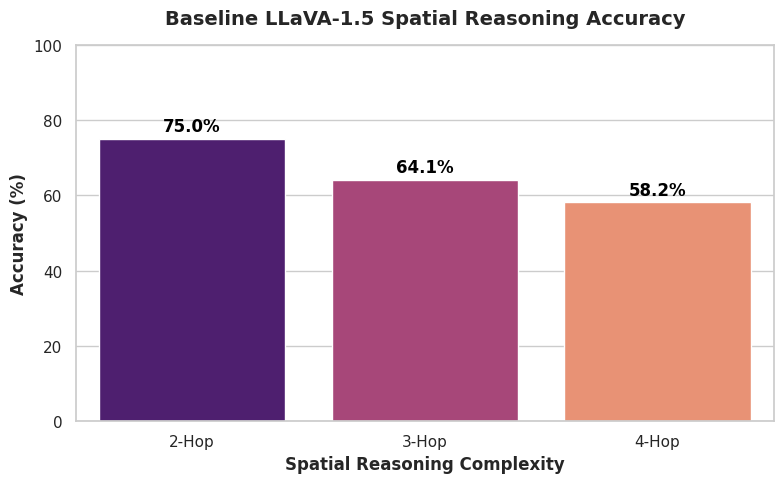

In [3]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the generated results
RESULTS_PATH = "/kaggle/working/baseline_results.json"

try:
    with open(RESULTS_PATH, "r") as f:
        results = json.load(f)
except FileNotFoundError:
    print(f"Error: Could not find {RESULTS_PATH}. Make sure your inference cell finished saving the file!")
    results = []

# 2. Initialize tracking dictionaries for each hop level
stats = {
    2: {"correct": 0, "total": 0},
    3: {"correct": 0, "total": 0},
    4: {"correct": 0, "total": 0}
}

# 3. Score the answers
for res in results:
    hop = res.get('hop_level')
    truth = str(res.get('ground_truth')).strip().lower()
    
    # Lowercase the model's answer to easily search for keywords
    answer = str(res.get('model_answer', '')).strip().lower()
    
    # Skip if the model failed to generate an answer for this image
    if not answer:
        continue 
        
    # Evaluation logic
    if truth == "yes":
        if "yes" in answer:
            stats[hop]["correct"] += 1
    elif truth == "no":
        # Check for negative indicators
        if "no" in answer or "not" in answer or "none" in answer:
            stats[hop]["correct"] += 1
    else:
        # Fallback for specific text answers (e.g., "shipping containers")
        if truth in answer:
            stats[hop]["correct"] += 1
            
    stats[hop]["total"] += 1

# 4. Print the final metrics
print("=== BASELINE LLAVA-1.5 (7B) ACCURACY ===")
accuracies = []
hop_labels = []

for hop in sorted(stats.keys()):
    if stats[hop]["total"] > 0:
        correct = stats[hop]["correct"]
        total = stats[hop]["total"]
        acc = (correct / total) * 100
        
        accuracies.append(acc)
        hop_labels.append(f"{hop}-Hop")
        print(f"{hop}-Hop Questions: {acc:.2f}%  ({correct}/{total} correct)")

# 5. Generate a visualization for your report
if accuracies:
    # Set seaborn style for cleaner graphs
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 5))
    
    # Create the bar chart (FIXED WARNING HERE)
    ax = sns.barplot(x=hop_labels, y=accuracies, hue=hop_labels, palette="magma", legend=False)
    
    plt.title("Baseline LLaVA-1.5 Spatial Reasoning Accuracy", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("Accuracy (%)", fontsize=12, fontweight='bold')
    plt.xlabel("Spatial Reasoning Complexity", fontsize=12, fontweight='bold')
    plt.ylim(0, 100)
    
    # Add percentage labels on top of the bars
    for i, v in enumerate(accuracies):
        plt.text(i, v + 2, f"{v:.1f}%", ha='center', color='black', fontweight='bold')
        
    plt.tight_layout()
    plt.show()